# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [67]:
# Please, enter your name and RA number in the lines below:
print("Student 1", "|", "RA1")
print("Rafael Masato Haga Costa", "|", "247348")
print("Thiago Nadim Martinho", "|", "239426")  # You may remove this line if you are only 2 students in the group

Student 1 | RA1
Rafael Masato Haga Costa | 247348
Thiago Nadim Martinho | 239426


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

In [68]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
from torch import optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 42
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [69]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell




from typing import Any
def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


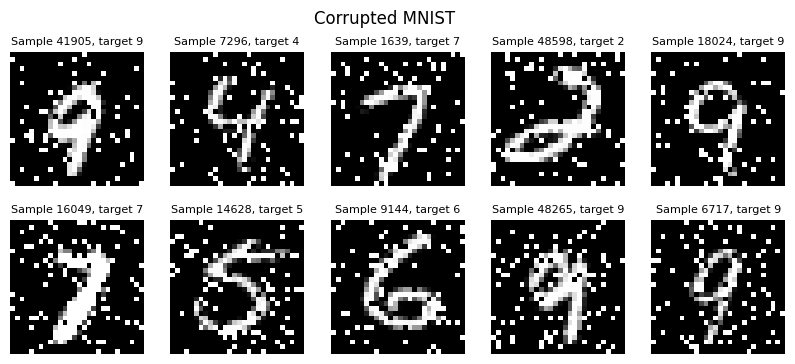

In [70]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

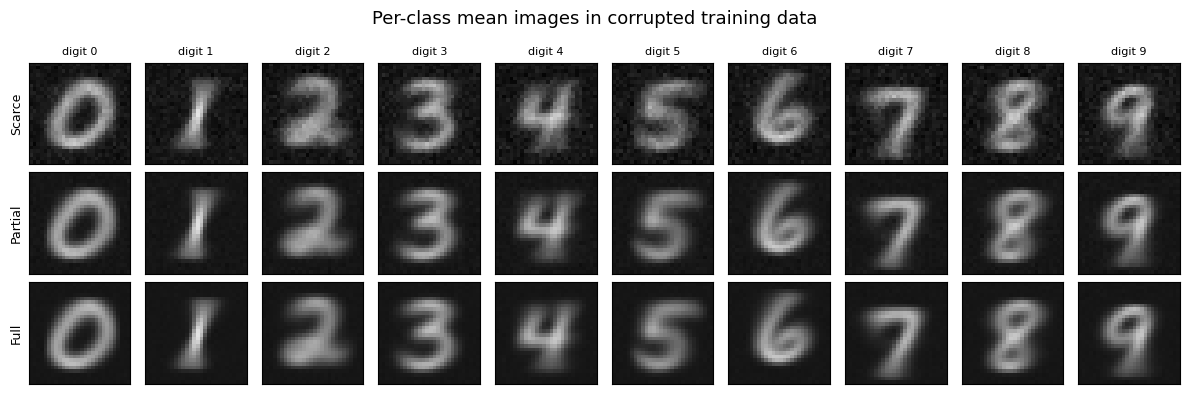

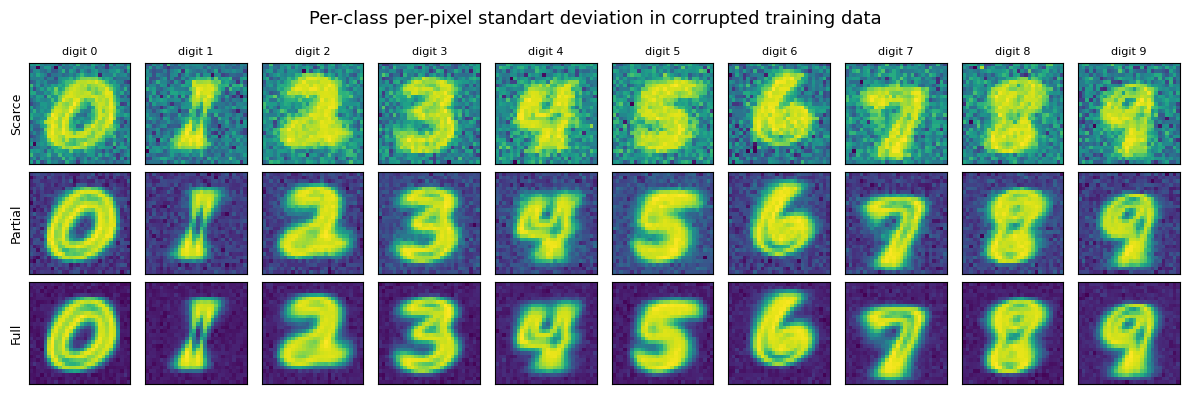

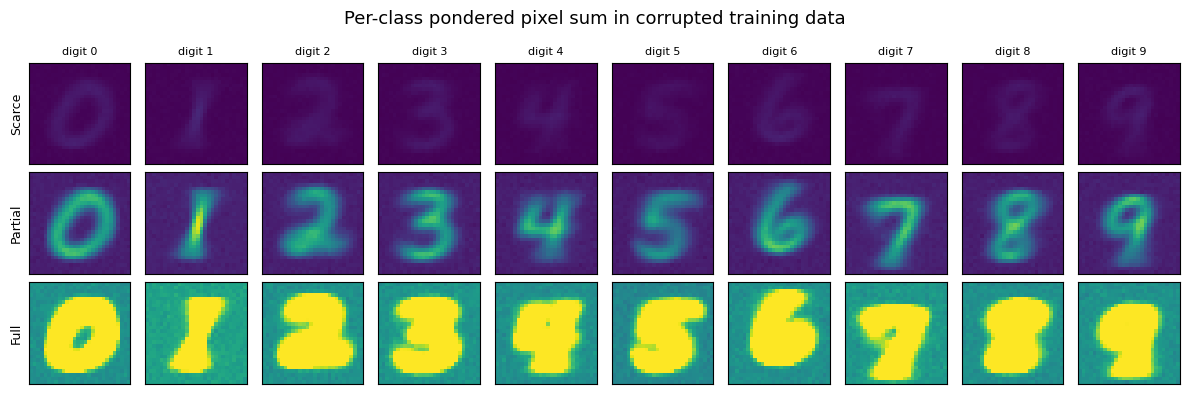

In [71]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

mean_fig, mean_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
std_fig, std_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
sum_fig, sum_axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))

for digit in range(10):
    mean_axs[0, digit].set_title(f"digit {digit}", fontsize=8)
    std_axs[0, digit].set_title(f"digit {digit}", fontsize=8)
    sum_axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        sum_weight = 1e-3

        mean_img = X[mask].mean(axis=0)
        std_img = X[mask].std(axis=0)
        sum_img = (X[mask]*sum_weight).sum(axis=0)

        mean_axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        mean_axs[i, digit].set_xticks([])
        mean_axs[i, digit].set_yticks([])
        std_axs[i, digit].imshow(std_img, cmap="viridis", vmin=std_img.min(), vmax=std_img.max())
        std_axs[i, digit].set_xticks([])
        std_axs[i, digit].set_yticks([])
        sum_axs[i, digit].imshow(sum_img, cmap="viridis", vmin=0, vmax=255)
        sum_axs[i, digit].set_xticks([])
        sum_axs[i, digit].set_yticks([])

    mean_axs[i, 0].set_ylabel(f"{name}", fontsize=9)
    std_axs[i, 0].set_ylabel(f"{name}", fontsize=9)
    sum_axs[i, 0].set_ylabel(f"{name}", fontsize=9)



mean_fig.suptitle("Per-class mean images in corrupted training data", fontsize=13)
mean_fig.tight_layout()

std_fig.suptitle("Per-class per-pixel standart deviation in corrupted training data", fontsize=13)
std_fig.tight_layout()
 
sum_fig.suptitle("Per-class pondered pixel sum in corrupted training data", fontsize=13)
sum_fig.tight_layout()

plt.show()

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.



A distorção aplicada consiste em flips aleatórios aplicados as imagens do dataset original. Têm-se um forte indicativo de que o ruído adicionado é uniformemente distribuído pela imagem e independe da classe, ou seja, não há uma observação que revele alguma corrupção sistematica dentro de uma mesma classe ou que se diferencie entre classes distíntas.

A hipótese se sustenta pela análise conjunta das três figuras geradas acima. A visualização da média dos pixeis na maior amostra não revela o aparecimento de objetos estranhos na imagem, revelando que mesmo que existam distorções elas se distribuem de forma tal que não exista uma maior dos erros (de mesmo valor) em posições específicas da figura, que preserva a forma do dos dígitos da amostra original.

Em adição, a análise dos desvios padrões nos valores dos pixeis apontam que existe uma grande variação na silhueta dos dígitos, mas não em outros pontos da imagem. A primeira é esperada, e provavelmente presente nas amostras integras do MNIST, dada as pequenas variações na escrita de cada dígito; já a segunda, associada ao ruído, reforça que não existem pontos onde o ruído se pronuncia de forma mais recorrente. Combinando a conclusão com o comentário do parágrafo anterior, segue que de forma geral, para um número grande de amostras, o valor em cada posição da imagem se mantém como na figura original.

Por fim, avaliando a relação entre o regime de dados e o treinamento do modelo, é de se esperar que os conjuntos menores incorram em uma maior probabilidade de overfitting do modelo modelo a ser treinado, que tende a se ajustar ao ruído adicionado pela corrupção do MNIST. A hipótese deriva de outra análise das médias, na medida em que se verifica um pronunciamento mais relevante do ruído no agregado do regime **Scarse**, logo se concluí que ele terá mais impacto no treinamento do modelo. No modelo maior **Full** a presença do ruído é amortizado entre as amostras, o que resulta em um menor impacto no treinamento. 

Isso destaca que em regimes menores, o impacto de cada amostra tende a ser mais relevante, logo o ruído presente leva a uma maior chance de overfitting e erros de teste mais significativos. Neste caso, um modelo menos flexível é preferível, uma vez que reduz o impacto de um ponto específico no treino.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [72]:
def preprocess_data(
        X: NDArray[np.float64], y: NDArray[np.float64]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:

    X = X/255.0

    return X, y

for name in data_regimes:
    X, y = data_regimes[name]
    data_regimes[name] = preprocess_data(X, y)


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

Em relação á escala, como se sabe que cada pixel assume algum valor no intervalo [0, 255], a normalização é realizada simplesmente dividindo cada posição da amostra por 255, levando a valores compreendidos entre 0 e 1.

A normalização foi aplicado exclusivamente nos dados de treino, e dado sua simplicidade nenhuma característica estatística da amostra foi necessária para realizar a operação. Logo não há risco de vazamento de dados nesta etapa. No momento do teste o mesmo valor de 255 deve ser utilizado para a normalização dos dados.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.


In [73]:
# Implementation goes here
from torch import nn

class LinearModel(nn.Module):
    
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)
        

def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()


def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []

    for _ in range(n_iter):
        optimizer.zero_grad()
        logits = model(X)

        base_loss = loss_fn(logits, y)

        l1_penalty = 0.0
        l2_penalty = 0.0

        if l1 > 0.0 or l2 > 0.0:
            for param in model.parameters():
                if l1 > 0.0:
                    l1_penalty += torch.sum(torch.abs(param))
                if l2 > 0.0:
                    l2_penalty += torch.sum(param ** 2)
        
        total_loss = base_loss + (l1 * l1_penalty) + (l2 * l2_penalty)        
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())

    return losses

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

In [74]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Training baseline models on Scarce-data regime
  lr=0.001 | final loss: 1.9377 | train acc: 0.5640
  lr=0.010 | final loss: 0.8131 | train acc: 0.8880
  lr=0.100 | final loss: 0.1448 | train acc: 0.9940
  lr=0.500 | final loss: 0.0258 | train acc: 1.0000


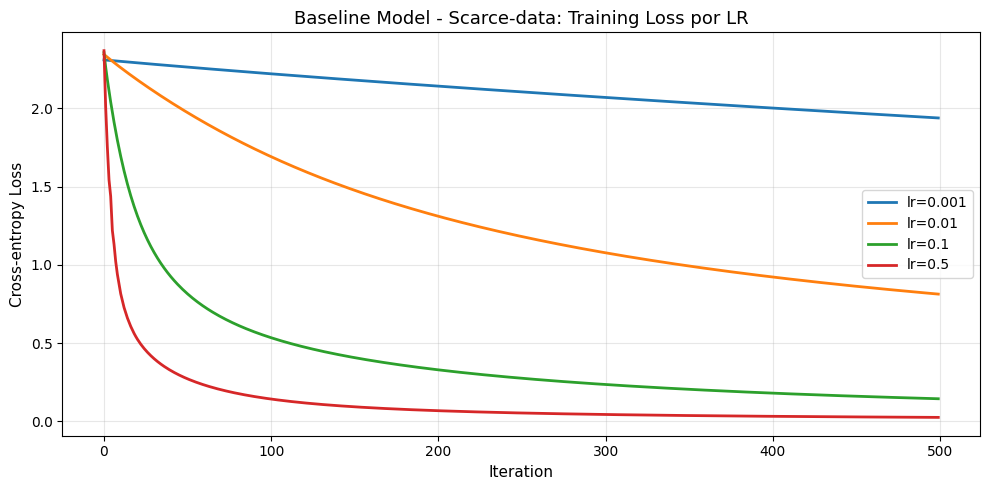


  Melhor LR: 0.5 — exibindo pesos aprendidos


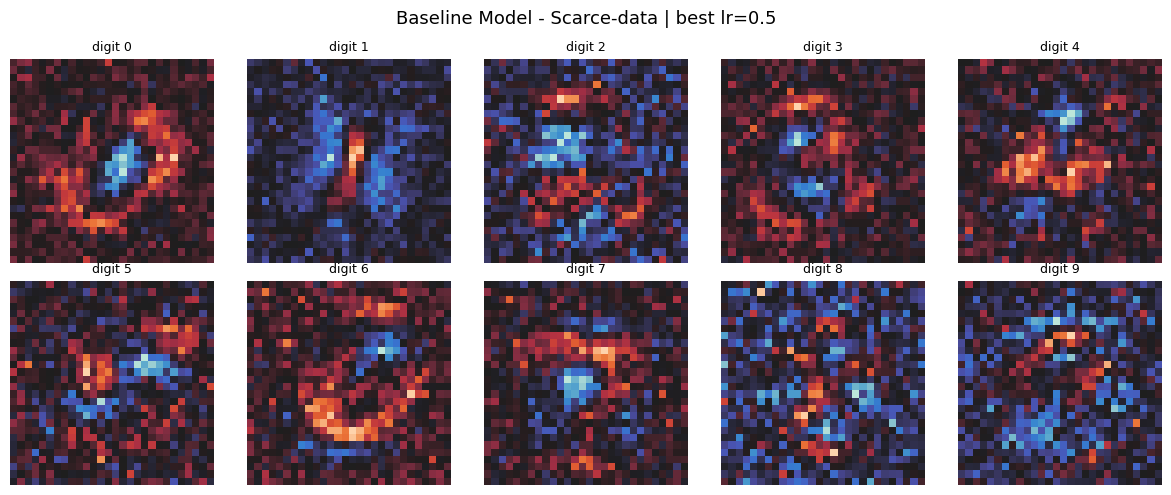


Training baseline models on Partial-data regime
  lr=0.001 | final loss: 2.0097 | train acc: 0.4775
  lr=0.010 | final loss: 0.9563 | train acc: 0.8134
  lr=0.100 | final loss: 0.4141 | train acc: 0.8907
  lr=0.500 | final loss: 0.2466 | train acc: 0.9416


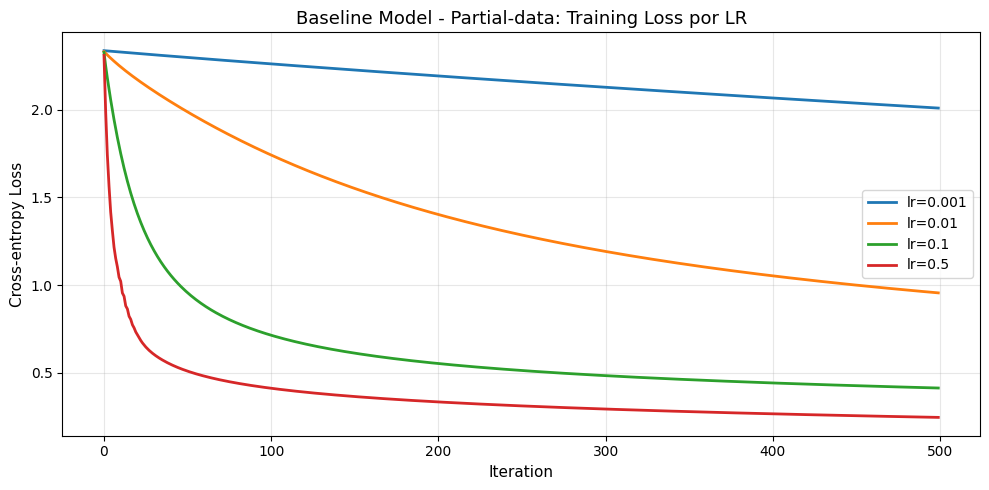


  Melhor LR: 0.5 — exibindo pesos aprendidos


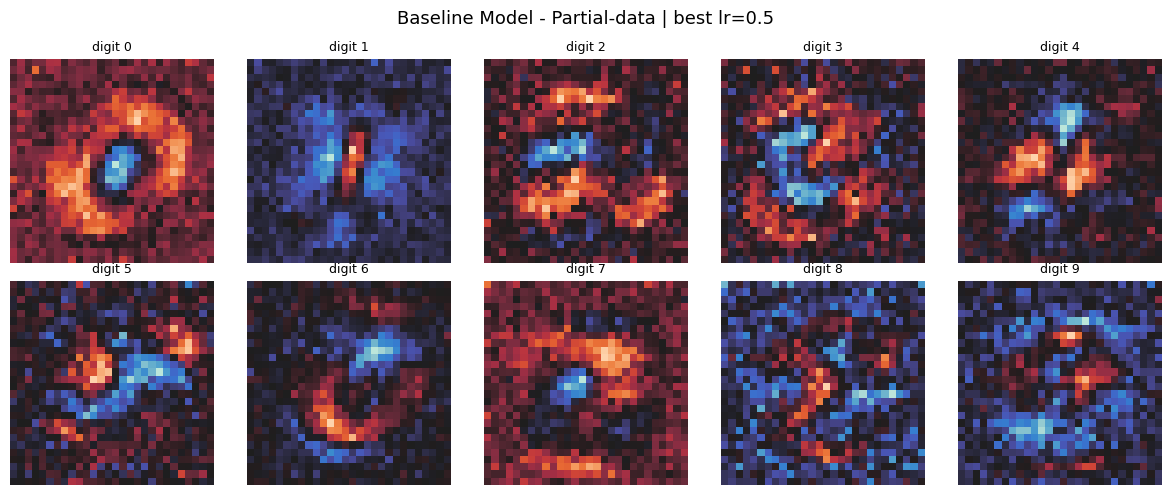


Training baseline models on Full-data regime
  lr=0.001 | final loss: 1.9989 | train acc: 0.4975
  lr=0.010 | final loss: 0.9690 | train acc: 0.8045
  lr=0.100 | final loss: 0.4670 | train acc: 0.8715
  lr=0.500 | final loss: 0.3676 | train acc: 0.8926


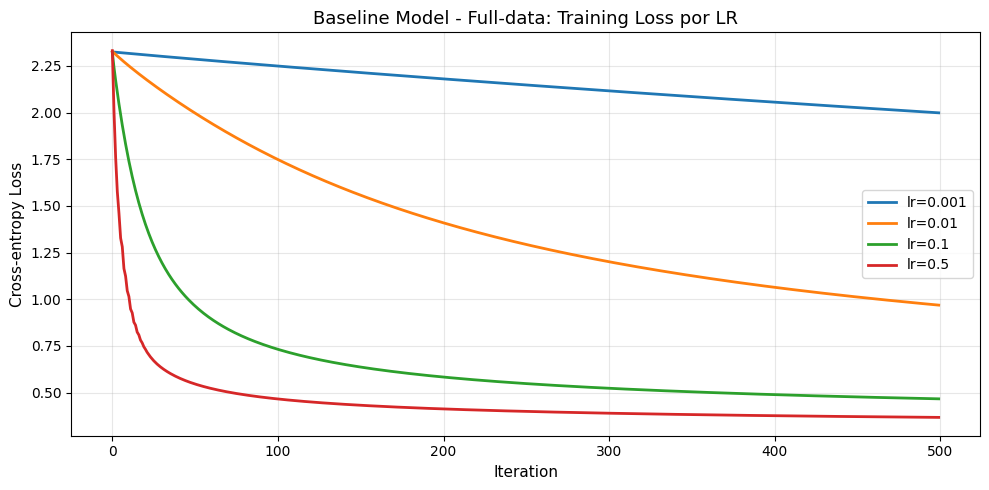


  Melhor LR: 0.5 — exibindo pesos aprendidos


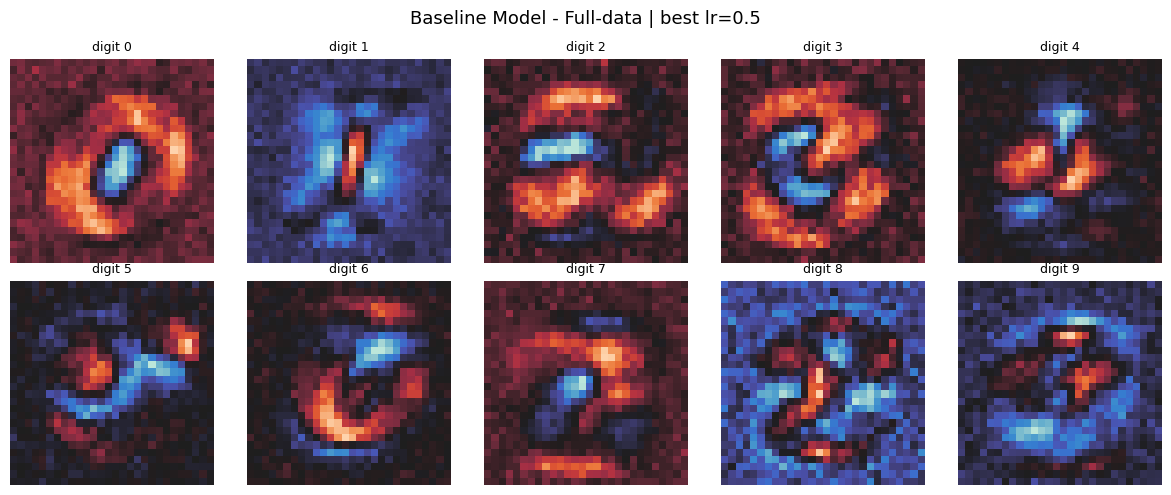

In [75]:
baselines = {}
n_iter = 500
learning_rates = [0.001, 0.01, 0.1, 0.5]

for regime_name in data_regimes:
    print(f"\n{'='*50}")
    print(f"Training baseline models on {regime_name}-data regime")
    print(f"{'='*50}")

    # Get data and convert to torch tensors
    X_train, y_train = data_regimes[regime_name]
    X_train = torch.FloatTensor(X_train.reshape(len(X_train), -1))  # Flatten to (N, 784)
    y_train = torch.LongTensor(y_train)

    baselines[regime_name] = {}

    # --- Train one model per LR ---
    for lr in learning_rates:
        model = LinearModel(in_features=784, num_classes=10)
        losses = train(model, X_train, y_train, n_iter=n_iter, lr=lr, l1=0.0, l2=0.0)

        with torch.no_grad():
            acc = accuracy(model(X_train), y_train)

        baselines[regime_name][lr] = {
            'model': model,
            'losses': losses,
            'final_loss': losses[-1],
            'train_acc': acc
        }

        print(f"  lr={lr:.3f} | final loss: {losses[-1]:.4f} | train acc: {acc:.4f}")

    # --- Plot all LR curves together ---
    plt.figure(figsize=(10, 5))
    for lr in learning_rates:
        plt.plot(baselines[regime_name][lr]['losses'], label=f"lr={lr}", linewidth=2)

    plt.title(f"Baseline Model - {regime_name}-data: Training Loss por LR", fontsize=13)
    plt.xlabel("Iteration", fontsize=11)
    plt.ylabel("Cross-entropy Loss", fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Visualize weights of best model (lowest final loss) ---
    best_lr = min(learning_rates, key=lambda lr: baselines[regime_name][lr]['final_loss'])
    best_model = baselines[regime_name][best_lr]['model']
    weights = best_model.linear.weight.detach().cpu().numpy()

    print(f"\n  Melhor LR: {best_lr} — exibindo pesos aprendidos")
    plot_weights(weights, f"Baseline Model - {regime_name}-data | best lr={best_lr}")

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

Os valores dos pesos no mapa de calor representam os coeficientes da matriz W do modelo linear, onde cada linha corresponde a uma classe dos dígitos de 0 a 9, que foi remodelada para o formato 28x28 (784) para permitir a interpretação visual. Os valores positivos, exibidos em tons quentes (vermelho, laranja, amarelo), indicam pixels que aumentam a probabilidade de a imagem pertencer a uma classe específica (número), enquanto os valores negativos em azul sinalizam áreas que diminuem essa probabilidade. Visualmente, esses padrões revelam a geometria que o modelo associa a cada número, funcionando como uma máscara que busca coincidências entre os pixels acesos da entrada e o conhecimento armazenado nos pesos.

Ao comparar os modelos, a diferença fundamental reside na nitidez desses moldes e na presença de ruído, o que evidencia a importância da disponibilidade de dados na generalização do modelo para evitar overfitting.

Para o **Scarce-data**, são apresentados mapas altamente ruidosos e granulados, com difícil identificação das classes, e os contornos dos dígitos aparecem “sujos” por interferências externas. Como resultado, observa-se também uma perda final de treino extremamente baixa para learning rates mais altos, chegando a (0.0259) com (lr=0.500), além de *train accuracy* de (1.0000). Isso indica um ajuste excessivo aos dados disponíveis, caracterizando overfitting. Como há poucas amostras, o modelo acaba memorizando padrões específicos e até corrupções aleatórias como se fossem características reais dos dígitos. Nota-se também que learning rates pequenos, como (0.001), não conseguem otimizar adequadamente o modelo nesse cenário, resultando em *loss* elevada ((1.9783)) e baixa acurácia ((0.4940)), enquanto learning rates maiores aceleram drasticamente o processo de memorização devido ao número reduzido de exemplos disponíveis.

Para o regime **Partial-data**, temos silhuetas mais definidas que no Scarce-data, mas ainda retendo vestígios de granulação que apenas o conjunto completo consegue filtrar quase integralmente. Com uma *final loss* de (0.2464) para (lr=0.500), significativamente maior que a observada no Scarce-data ((0.0259)), já é possível perceber uma redução do overfitting. Com aproximadamente **10.000 amostras**, o modelo encontra maior dificuldade para “decorar” cada pixel individualmente, sendo forçado a aprender padrões mais gerais da estrutura dos dígitos. Além disso, os diferentes learning rates mostram um comportamento mais equilibrado: valores baixos ainda apresentam subtreinamento, enquanto valores intermediários e altos conseguem melhorar a convergência sem atingir a memorização extrema observada no conjunto escasso.

Para o **Full-data**, são exibidos os moldes mais nítidos e suaves, com perturbações aleatórias neutralizadas pelo cancelamento de ruído proporcionado pelo grande volume de dados. Como resultado, temos uma *final loss* superior ((0.3676) para (lr=0.500)) em comparação aos outros regimes, mas isso aponta para um aprendizado mais robusto e generalizável. Ao focar na distribuição geral dos dígitos em vez de memorizar pixels ruidosos isolados, o modelo desenvolve representações mais estáveis e menos sensíveis às particularidades das amostras individuais. Com cerca de **60.000 amostras**, os learning rates mais altos continuam proporcionando melhor convergência, porém com ganhos mais moderados, já que a maior quantidade de dados dificulta o ajuste perfeito do conjunto de treino. Isso demonstra como o aumento da disponibilidade de dados atua como uma forma natural de regularização, estabilizando o aprendizado e reduzindo o overfitting.


---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.



Regime: Scarce

  Regularizer: L1

    lr=0.01
      λ=0.0001 | CV acc: 0.7830 ± 0.0304
      λ=0.0010 | CV acc: 0.7800 ± 0.0318
      λ=0.0100 | CV acc: 0.7190 ± 0.0340
      λ=0.1000 | CV acc: 0.2890 ± 0.0983
      λ=1.0000 | CV acc: 0.1360 ± 0.0325

    lr=0.1
      λ=0.0001 | CV acc: 0.8230 ± 0.0298
      λ=0.0010 | CV acc: 0.8300 ± 0.0243
      λ=0.0100 | CV acc: 0.7440 ± 0.0292
      λ=0.1000 | CV acc: 0.3000 ± 0.0371
      λ=1.0000 | CV acc: 0.1550 ± 0.0261

    lr=0.5
      λ=0.0001 | CV acc: 0.8230 ± 0.0269
      λ=0.0010 | CV acc: 0.8140 ± 0.0218
      λ=0.0100 | CV acc: 0.5970 ± 0.0415
      λ=0.1000 | CV acc: 0.2520 ± 0.0542
      λ=1.0000 | CV acc: 0.2250 ± 0.0302

  Regularizer: L2

    lr=0.01
      λ=0.0001 | CV acc: 0.7730 ± 0.0311
      λ=0.0010 | CV acc: 0.7790 ± 0.0318
      λ=0.0100 | CV acc: 0.7800 ± 0.0391
      λ=0.1000 | CV acc: 0.7690 ± 0.0372
      λ=1.0000 | CV acc: 0.6380 ± 0.0538

    lr=0.1
      λ=0.0001 | CV acc: 0.8160 ± 0.0317
      λ=0.0010 | CV acc

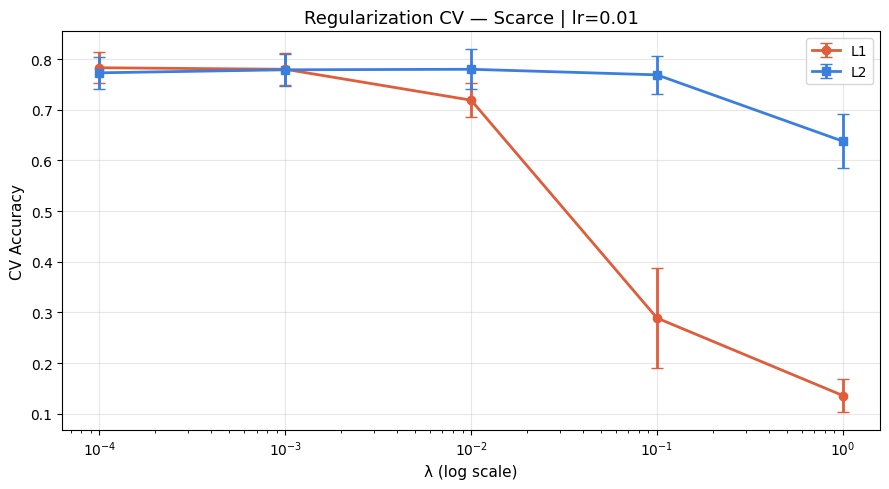

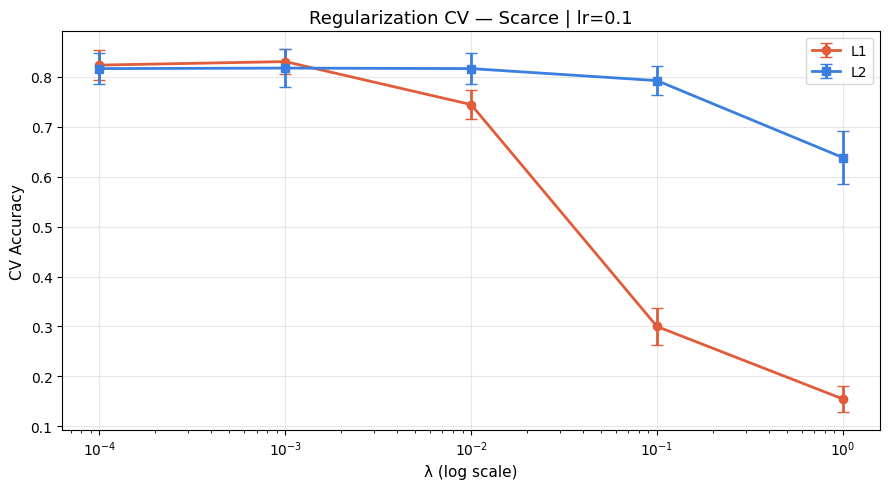

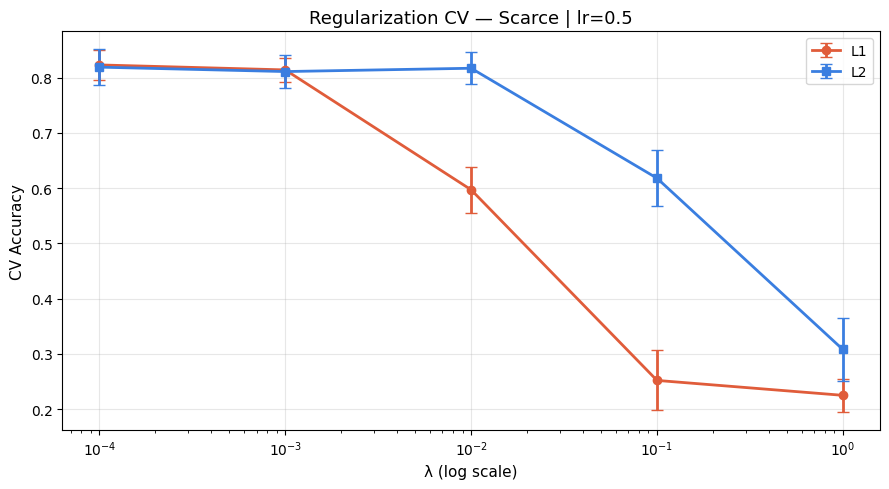


  [L1] Best lr=0.1, λ=0.001 (CV acc=0.8300)
         Train acc (full set): 0.9850


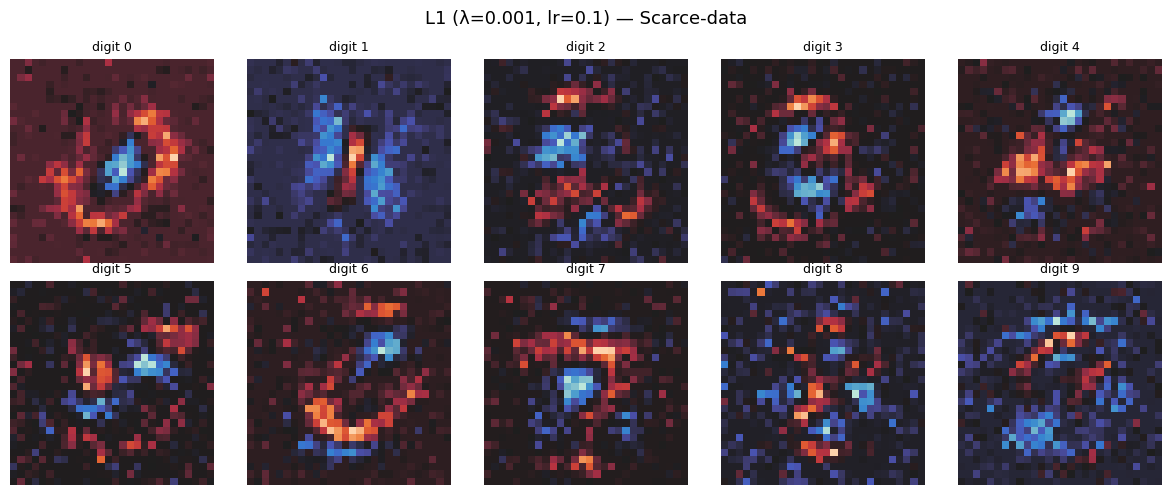


  [L2] Best lr=0.5, λ=0.0001 (CV acc=0.8190)
         Train acc (full set): 1.0000


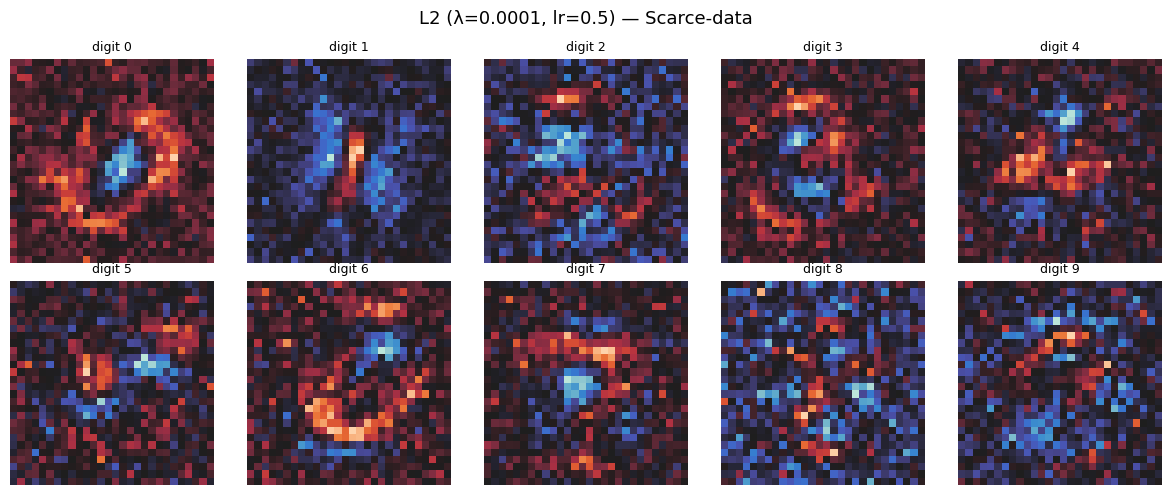


Regime: Partial

  Regularizer: L1

    lr=0.01
      λ=0.0001 | CV acc: 0.7993 ± 0.0116
      λ=0.0010 | CV acc: 0.8027 ± 0.0101
      λ=0.0100 | CV acc: 0.7532 ± 0.0120
      λ=0.1000 | CV acc: 0.3206 ± 0.0423
      λ=1.0000 | CV acc: 0.1333 ± 0.0124

    lr=0.1
      λ=0.0001 | CV acc: 0.8604 ± 0.0068
      λ=0.0010 | CV acc: 0.8565 ± 0.0055
      λ=0.0100 | CV acc: 0.7717 ± 0.0053
      λ=0.1000 | CV acc: 0.3086 ± 0.0383
      λ=1.0000 | CV acc: 0.1604 ± 0.0098

    lr=0.5
      λ=0.0001 | CV acc: 0.8580 ± 0.0052
      λ=0.0010 | CV acc: 0.8568 ± 0.0067
      λ=0.0100 | CV acc: 0.5798 ± 0.0173
      λ=0.1000 | CV acc: 0.2266 ± 0.0424
      λ=1.0000 | CV acc: 0.2303 ± 0.0083

  Regularizer: L2

    lr=0.01
      λ=0.0001 | CV acc: 0.7992 ± 0.0070
      λ=0.0010 | CV acc: 0.8036 ± 0.0063
      λ=0.0100 | CV acc: 0.8034 ± 0.0119
      λ=0.1000 | CV acc: 0.7979 ± 0.0088
      λ=1.0000 | CV acc: 0.7346 ± 0.0118

    lr=0.1
      λ=0.0001 | CV acc: 0.8583 ± 0.0064
      λ=0.0010 | CV ac

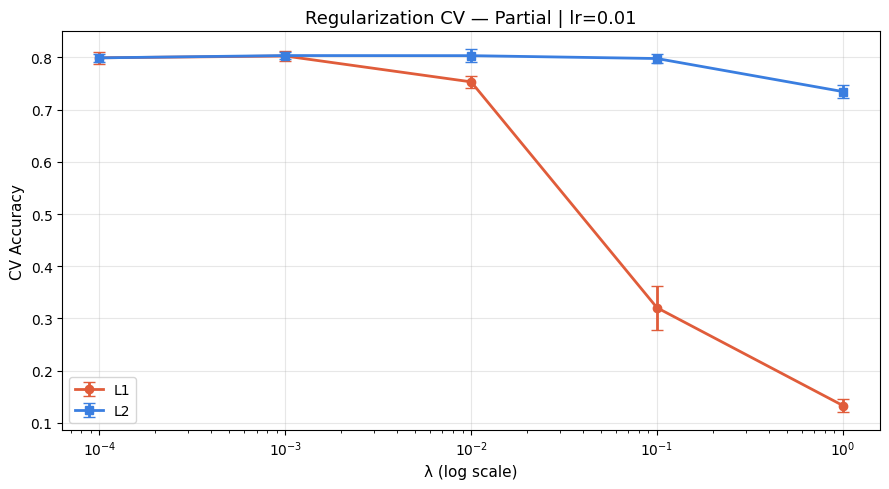

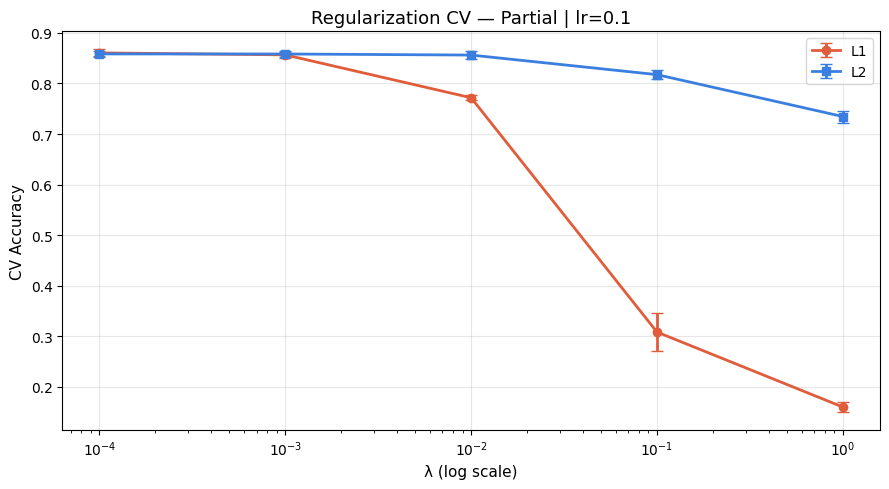

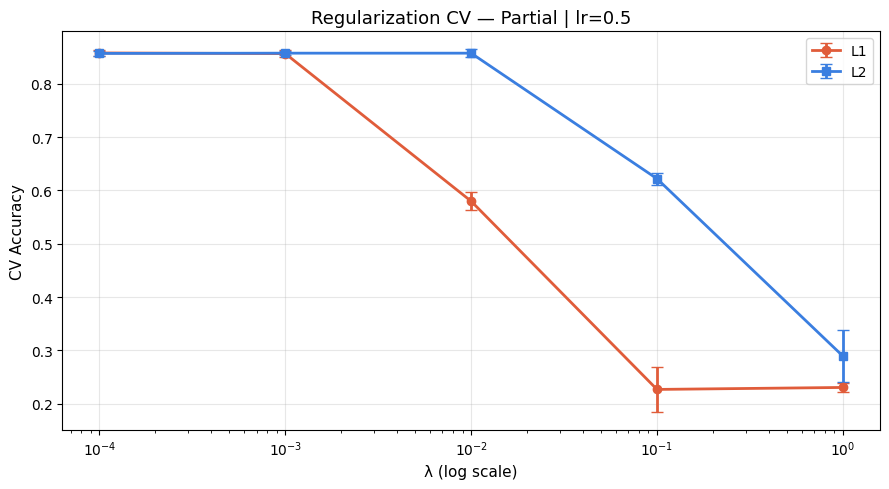


  [L1] Best lr=0.1, λ=0.0001 (CV acc=0.8604)
         Train acc (full set): 0.8908


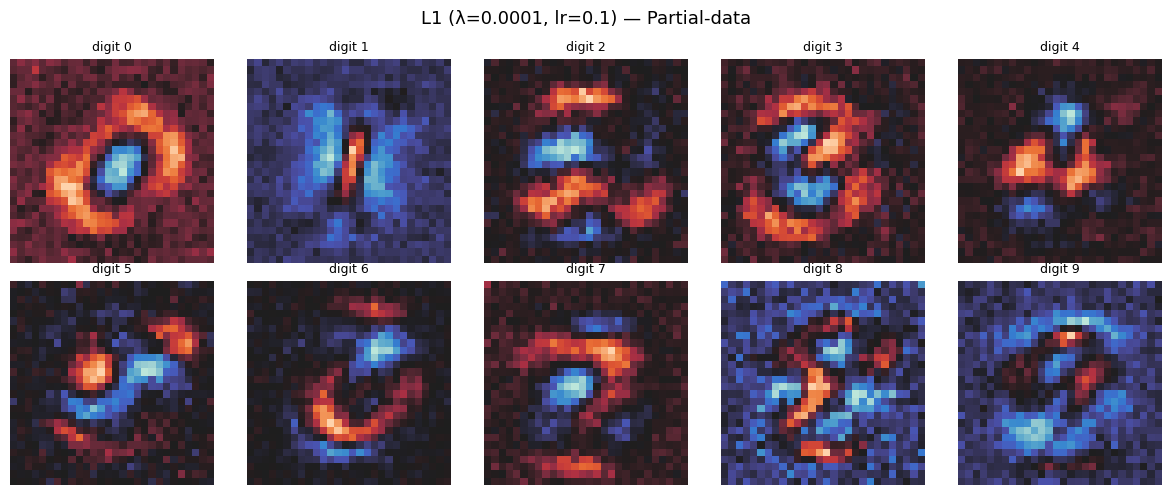


  [L2] Best lr=0.1, λ=0.0001 (CV acc=0.8583)
         Train acc (full set): 0.8937


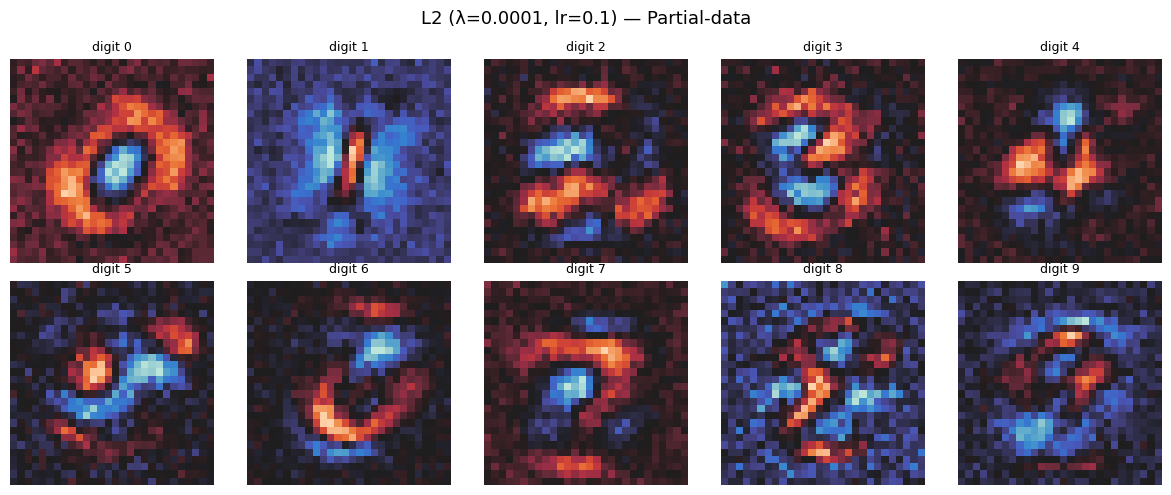


Regime: Full

  Regularizer: L1

    lr=0.01
      λ=0.0001 | CV acc: 0.8038 ± 0.0021
      λ=0.0010 | CV acc: 0.8038 ± 0.0023
      λ=0.0100 | CV acc: 0.7556 ± 0.0039
      λ=0.1000 | CV acc: 0.3104 ± 0.0366
      λ=1.0000 | CV acc: 0.1223 ± 0.0114

    lr=0.1
      λ=0.0001 | CV acc: 0.8649 ± 0.0023
      λ=0.0010 | CV acc: 0.8571 ± 0.0019
      λ=0.0100 | CV acc: 0.7750 ± 0.0023
      λ=0.1000 | CV acc: 0.2944 ± 0.0320
      λ=1.0000 | CV acc: 0.1659 ± 0.0147

    lr=0.5
      λ=0.0001 | CV acc: 0.8784 ± 0.0033
      λ=0.0010 | CV acc: 0.8650 ± 0.0024
      λ=0.0100 | CV acc: 0.5891 ± 0.0048
      λ=0.1000 | CV acc: 0.2659 ± 0.0222
      λ=1.0000 | CV acc: 0.2344 ± 0.0410

  Regularizer: L2

    lr=0.01
      λ=0.0001 | CV acc: 0.8039 ± 0.0034
      λ=0.0010 | CV acc: 0.8029 ± 0.0031
      λ=0.0100 | CV acc: 0.8030 ± 0.0013
      λ=0.1000 | CV acc: 0.7977 ± 0.0016
      λ=1.0000 | CV acc: 0.7340 ± 0.0024

    lr=0.1
      λ=0.0001 | CV acc: 0.8650 ± 0.0020
      λ=0.0010 | CV acc: 

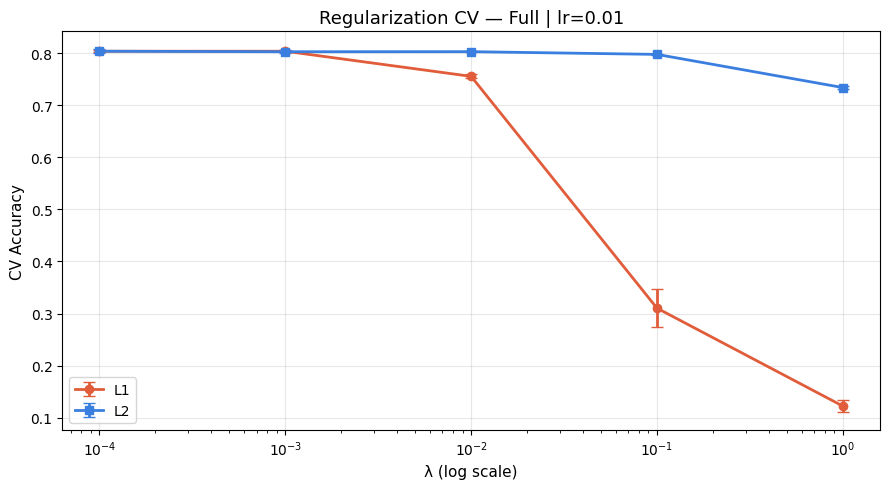

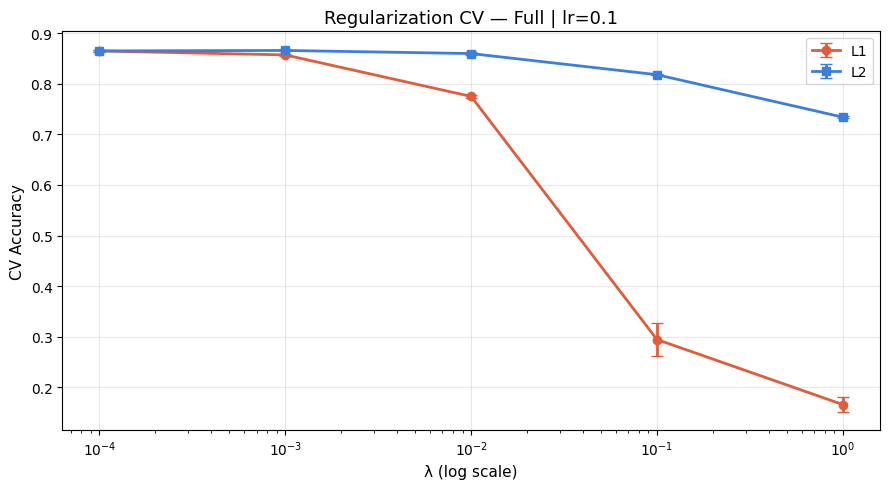

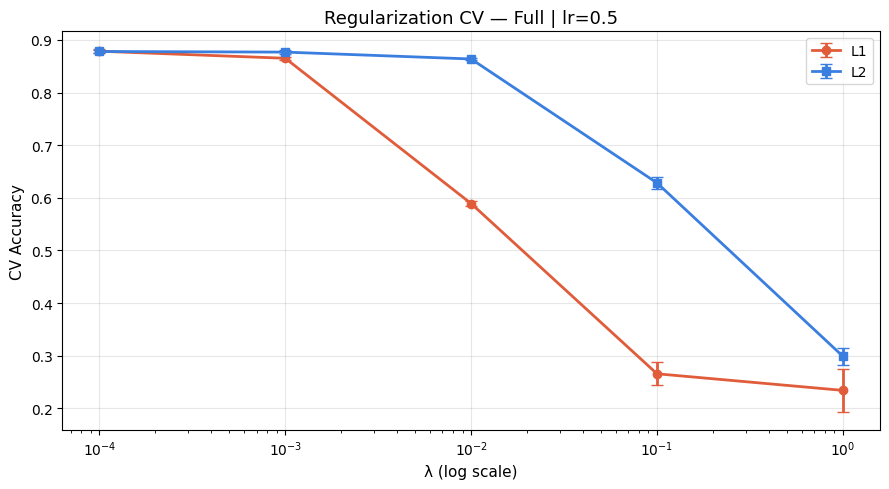


  [L1] Best lr=0.5, λ=0.0001 (CV acc=0.8784)
         Train acc (full set): 0.8904


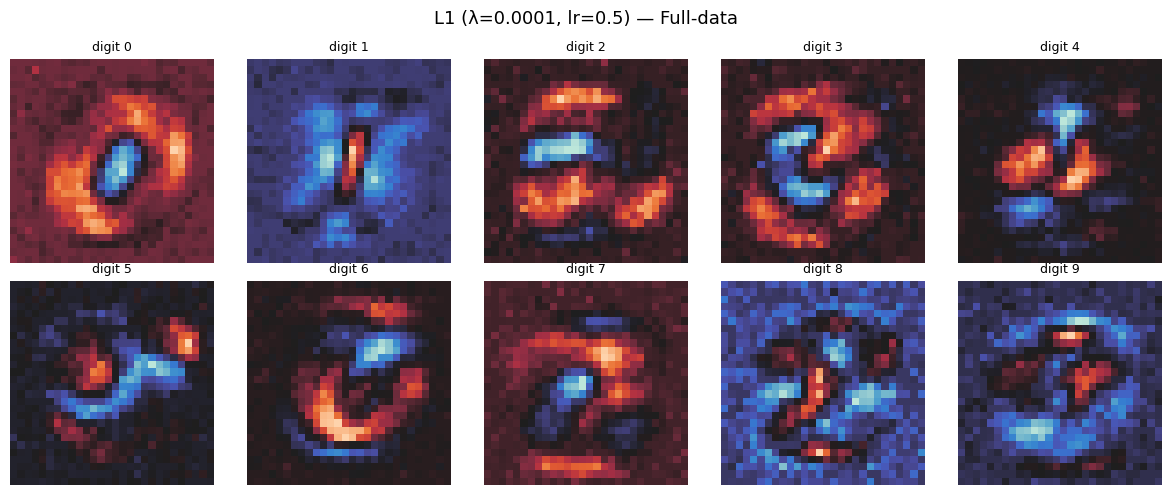


  [L2] Best lr=0.5, λ=0.0001 (CV acc=0.8779)
         Train acc (full set): 0.8921


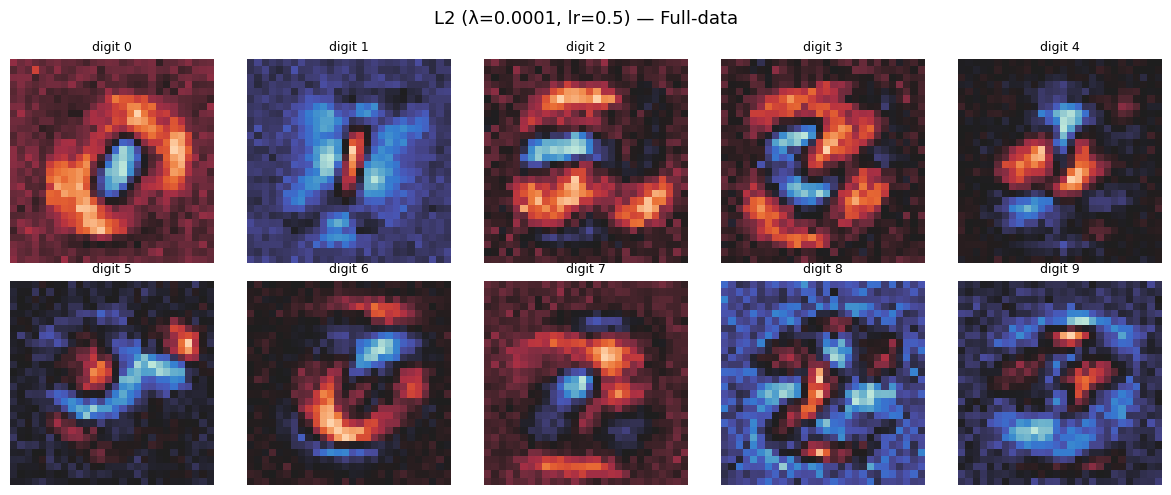

In [76]:
# ============================================================
# Part 3 — Regularization with K-Fold Cross-Validation
# ============================================================

from sklearn.model_selection import KFold
import torch
import numpy as np
import matplotlib.pyplot as plt

n_iter        = 500
k_folds       = 5
lambda_vals   = [0.0001, 0.001, 0.01, 0.1, 1.0]
learning_rates = [0.01, 0.1, 0.5]

reg_results  = {}   # reg_results[regime][reg_type][lr][lam]
final_models = {}   # final_models[regime][reg_type] = {model, best_lam, best_lr, ...}

for regime_name in data_regimes:
    print(f"\n{'='*60}")
    print(f"Regime: {regime_name}")
    print(f"{'='*60}")

    X_np, y_np = data_regimes[regime_name]
    X_np = X_np.reshape(len(X_np), -1).astype(np.float32)  # (N, 784)

    reg_results[regime_name]  = {'l1': {}, 'l2': {}}
    final_models[regime_name] = {}

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    # ----------------------------------------------------------
    # 3.1  Cross-validation sweep (reg_type × lr × λ)
    # ----------------------------------------------------------
    for reg_type in ['l1', 'l2']:
        print(f"\n  Regularizer: {reg_type.upper()}")
        reg_results[regime_name][reg_type] = {}

        for lr in learning_rates:
            print(f"\n    lr={lr}")
            reg_results[regime_name][reg_type][lr] = {}

            for lam in lambda_vals:
                fold_accs = []

                for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
                    X_tr  = torch.FloatTensor(X_np[train_idx])
                    y_tr  = torch.LongTensor(y_np[train_idx])
                    X_val = torch.FloatTensor(X_np[val_idx])
                    y_val = torch.LongTensor(y_np[val_idx])

                    model = LinearModel(in_features=784, num_classes=10)
                    train(
                        model, X_tr, y_tr, n_iter=n_iter,
                        lr=lr,
                        l1=lam if reg_type == 'l1' else 0.0,
                        l2=lam if reg_type == 'l2' else 0.0,
                    )

                    with torch.no_grad():
                        val_acc = accuracy(model(X_val), y_val)
                    fold_accs.append(val_acc)

                mean_acc = np.mean(fold_accs)
                std_acc  = np.std(fold_accs)

                reg_results[regime_name][reg_type][lr][lam] = {
                    'cv_accs':  fold_accs,
                    'mean_acc': mean_acc,
                    'std_acc':  std_acc,
                }

                print(f"      λ={lam:.4f} | CV acc: {mean_acc:.4f} ± {std_acc:.4f}")

    # ----------------------------------------------------------
    # 3.2  Plot: um gráfico por LR, L1 e L2 sobrepostos
    # ----------------------------------------------------------
    for lr in learning_rates:
        fig, ax = plt.subplots(figsize=(9, 5))

        for reg_type, marker, color in [('l1', 'o', '#e05c3a'), ('l2', 's', '#3a7ee0')]:
            means = [reg_results[regime_name][reg_type][lr][l]['mean_acc'] for l in lambda_vals]
            stds  = [reg_results[regime_name][reg_type][lr][l]['std_acc']  for l in lambda_vals]
            ax.errorbar(
                lambda_vals, means, yerr=stds,
                label=reg_type.upper(), marker=marker, linewidth=2,
                capsize=4, color=color,
            )

        ax.set_xscale('log')
        ax.set_xlabel('λ (log scale)', fontsize=11)
        ax.set_ylabel('CV Accuracy', fontsize=11)
        ax.set_title(f'Regularization CV — {regime_name} | lr={lr}', fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ----------------------------------------------------------
    # 3.3  Selecionar melhor (lr, λ) e treinar modelo final
    # ----------------------------------------------------------
    X_full = torch.FloatTensor(X_np)
    y_full = torch.LongTensor(y_np)

    for reg_type in ['l1', 'l2']:
        best_lr, best_lam = max(
            [(lr, lam) for lr in learning_rates for lam in lambda_vals],
            key=lambda p: reg_results[regime_name][reg_type][p[0]][p[1]]['mean_acc']
        )

        best_acc = reg_results[regime_name][reg_type][best_lr][best_lam]['mean_acc']
        print(f"\n  [{reg_type.upper()}] Best lr={best_lr}, λ={best_lam} (CV acc={best_acc:.4f})")

        final_model = LinearModel(in_features=784, num_classes=10)
        final_losses = train(
            final_model, X_full, y_full, n_iter=n_iter,
            lr=best_lr,
            l1=best_lam if reg_type == 'l1' else 0.0,
            l2=best_lam if reg_type == 'l2' else 0.0,
        )

        with torch.no_grad():
            final_acc = accuracy(final_model(X_full), y_full)

        final_models[regime_name][reg_type] = {
            'model':     final_model,
            'best_lam':  best_lam,
            'best_lr':   best_lr,
            'losses':    final_losses,
            'train_acc': final_acc,
        }

        print(f"         Train acc (full set): {final_acc:.4f}")

        weights = final_model.linear.weight.detach().cpu().numpy()
        plot_weights(weights, f"{reg_type.upper()} (λ={best_lam}, lr={best_lr}) — {regime_name}-data")

> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


(a)

Scarce: A accuracy se mantém estável para λ pequenos (0.0001–0.01 todos em torno de 0.82 com lr=0.1), mas cai bruscamente a partir de λ=0.1. Não há um ótimo nítido — há um platô largo seguido de colapso. O melhor é λ=0.01 com lr=0.1 (0.8220).
Partial: Comportamento semelhante — platô estável de λ=0.0001 até λ=0.01 (≈0.856–0.859 com lr=0.1), queda suave em λ=0.1 e colapso em λ=1.0. O platô é mais pronunciado que no Scarce, sugerindo que L2 leve não prejudica com mais dados.
Full: O platô é ainda mais robusto — com lr=0.5, a accuracy vai de 0.8785 (λ=0.0001) até 0.8636 (λ=0.01) com queda mínima, só colapsando em λ=0.1. Isso indica que mais dados tornam o modelo naturalmente mais resistente à regularização, e o ótimo de L2 fica em λ muito pequeno ou praticamente sem regularização.
Padrão geral: nenhum regime apresenta um ótimo em pico nítido para L2 — todos mostram platô seguido de degradação.


(b) e (c) 

Olhando as imagens dos três regimes, emerge um padrão claro que conecta quantidade de dados, λ selecionado e qualidade dos pesos aprendidos.

No regime **Scarce**, a diferença entre os modelos é a mais nítida visualmente. Como havia muito poucos dados, o modelo sem regularização se prendia fortemente aos ruídos e particularidades das poucas amostras disponíveis, resultando em mapas de calor bastante granulados e com contornos sujos. Os modelos regularizados, por sua vez, precisaram de um λ maior para conseguir generalizar (já que com poucos exemplos o risco de memorizar o ruído é muito maior), e isso se reflete visivelmente nos pesos: as silhuetas dos dígitos aparecem mais limpas e os granulados de fundo são mais suprimidos, tornando a diferença entre baseline e modelos regularizados bastante perceptível.

No regime **Partial**, a diferença começa a diminuir. Com mais amostras disponíveis, o próprio volume de dados já atua como uma forma de regularização natural, diluindo o efeito de ruídos individuais. O λ selecionado por CV foi menor que no Scarce, e os mapas de calor dos três modelos passam a ser mais parecidos entre si, embora ainda seja possível notar que os modelos regularizados apresentam pesos ligeiramente mais suaves.

No regime **Full**, a diferença é a menos perceptível dos três, já que com 60k amostras e um λ muito pequeno (0.0001) selecionado por CV, os três modelos aprenderam representações virtualmente equivalentes. Ainda assim, mesmo nesse cenário, é possível notar principalmente no L1 um leve alisamento dos granulados de fundo (especialmente nos dígitos 5, 7 e 9), sugerindo que a penalização L1 começa a exercer sua característica de zerar pesos de baixa magnitude (que correspondem justamente aos pixels ruidosos) mesmo com λ muito conservador. O L2, com o mesmo λ, não exibe esse efeito de forma perceptível (seus pesos de fundo são tão ruidosos quanto os do baseline), pois a penalização quadrática encolhe todos os pesos proporcionalmente sem privilegiar o zeramento dos menores.

Quanto à supressão da corrupção, a conclusão geral é que a regularização foi mais decisiva onde os dados eram escassos, e foi progressivamente menos necessária à medida que o volume de dados aumentava. O λ selecionado por CV capturou esse comportamento corretamente: maior no Scarce (onde generalizar era difícil) e menor no Full (onde os dados já faziam esse trabalho).

(d)

Como os três modelos aprenderam pesos estruturalmente muito similares no regime Full-data, a diferença de performance em dados limpos provavelmente será pequena entre eles. Para esse regime, a quantidade de dados (60k amostras) foi suficiente para forçar o modelo a generalizar, fazendo mais trabalho de regularização do que o próprio λ selecionado por CV.
No entanto, analisando os mapas de calor com atenção, o L1 se mostra ligeiramente mais capaz de não se prender aos ruídos da corrupção: seus pesos de fundo aparecem visivelmente menos granulados que os do baseline e do L2, sugerindo que a penalização L1 já começou a zerar os pesos associados a pixels ruidosos mesmo com λ muito conservador. Essa característica de produzir representações mais limpas, sem sacrificar a estrutura essencial dos dígitos, é exatamente o que se espera de um bom preditor em dados limpos.
Por isso, a predição é que o L1 será o melhor modelo em dados de teste limpos, seguido do L2 (que encolhe pesos suavemente mas não elimina o ruído com a mesma eficácia) e por último o baseline (que absorveu a corrupção sem nenhum mecanismo de contenção).

---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.


Regime     | Modelo     | Corr Acc   | Clean Acc  | Gap     
-------------------------------------------------------
Scarce     | BASELINE   | 0.8318    | 0.8682    | -0.0364
Scarce     | L1         | 0.8229    | 0.8368    | -0.0139
Scarce     | L2         | 0.8246    | 0.8415    | -0.0169
Partial    | BASELINE   | 0.8747    | 0.8917    | -0.0170
Partial    | L1         | 0.8384    | 0.8501    | -0.0117
Partial    | L2         | 0.8388    | 0.8486    | -0.0098
Full       | BASELINE   | 0.8872    | 0.8990    | -0.0118
Full       | L1         | 0.8408    | 0.8493    | -0.0085
Full       | L2         | 0.8383    | 0.8505    | -0.0122


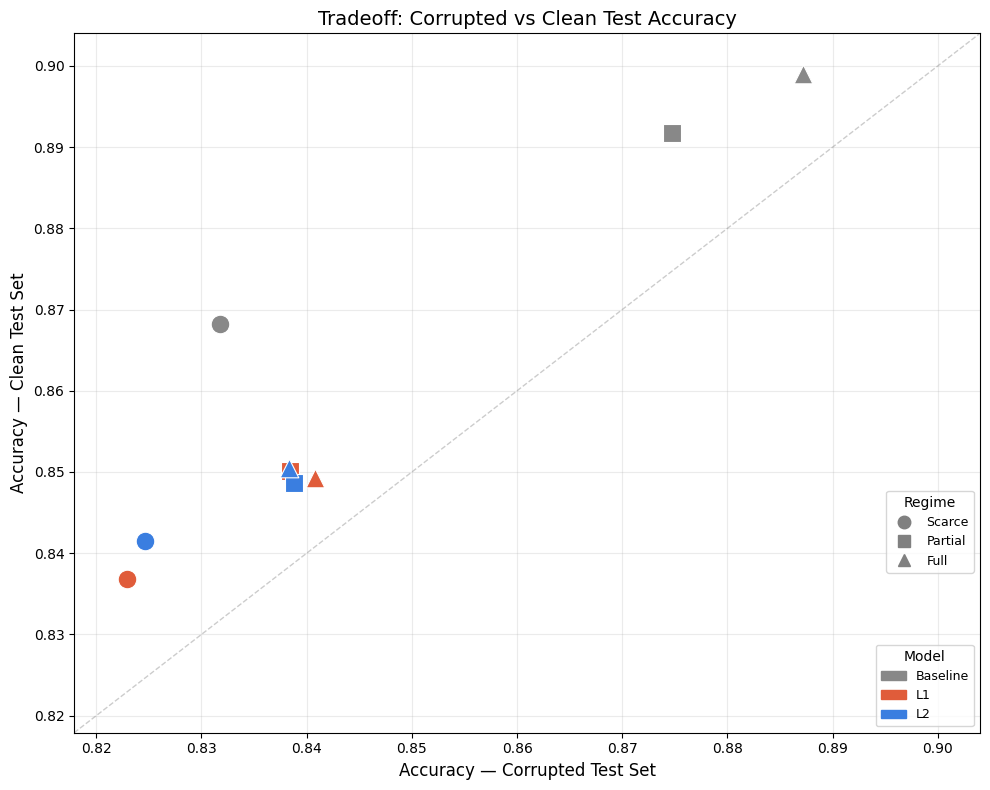

In [77]:
# ============================================================
# 4.2  Tradeoff plot: Corrupted Acc vs Clean Acc
# ============================================================
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Converter lista de dicts para dict aninhado
test_results_dict = {}
for res in test_results:
    regime = res['Regime']
    model  = res['Model'].lower()
    if regime not in test_results_dict:
        test_results_dict[regime] = {}
    test_results_dict[regime][model] = {
        'acc_corrupted': res['Corr_Acc'],
        'acc_clean':     res['Clean_Acc'],
    }

# Print tabela
print(f"\n{'Regime':<10} | {'Modelo':<10} | {'Corr Acc':<10} | {'Clean Acc':<10} | {'Gap':<8}")
print("-" * 55)
for res in test_results:
    gap = res['Corr_Acc'] - res['Clean_Acc']
    print(f"{res['Regime']:<10} | {res['Model'].upper():<10} | {res['Corr_Acc']:.4f}    | {res['Clean_Acc']:.4f}    | {gap:.4f}")

# Plot
markers = {'Scarce': 'o', 'Partial': 's', 'Full': '^'}
colors  = {'baseline': '#888888', 'l1': '#e05c3a', 'l2': '#3a7ee0'}
labels  = {'baseline': 'Baseline', 'l1': 'L1', 'l2': 'L2'}

fig, ax = plt.subplots(figsize=(10, 8))

for regime_name in test_results_dict:
    for model_type in ['baseline', 'l1', 'l2']:
        r = test_results_dict[regime_name][model_type]
        ax.scatter(
            r['acc_corrupted'], r['acc_clean'],
            color=colors[model_type],
            marker=markers[regime_name],
            s=180, zorder=5, edgecolors='white', linewidths=0.8,
        )

# Diagonal reference
all_vals = (
    [test_results_dict[r][m]['acc_corrupted'] for r in test_results_dict for m in ['baseline','l1','l2']] +
    [test_results_dict[r][m]['acc_clean']     for r in test_results_dict for m in ['baseline','l1','l2']]
)
pad  = 0.005
lmin = min(all_vals) - pad
lmax = max(all_vals) + pad
ax.plot([lmin, lmax], [lmin, lmax], '--', color='gray', linewidth=1, alpha=0.4)
ax.set_xlim(lmin, lmax)
ax.set_ylim(lmin, lmax)

# Legendas separadas
color_legend = [
    mpatches.Patch(color=colors['baseline'], label='Baseline'),
    mpatches.Patch(color=colors['l1'],       label='L1'),
    mpatches.Patch(color=colors['l2'],       label='L2'),
]
symbol_legend = [
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=9, label='Scarce'),
    mlines.Line2D([], [], color='gray', marker='s', linestyle='None', markersize=9, label='Partial'),
    mlines.Line2D([], [], color='gray', marker='^', linestyle='None', markersize=9, label='Full'),
]

leg1 = ax.legend(handles=color_legend,  title='Model',  fontsize=9,
                 loc='lower right', bbox_to_anchor=(1.0, 0.0))
leg2 = ax.legend(handles=symbol_legend, title='Regime', fontsize=9,
                 loc='lower right', bbox_to_anchor=(1.0, 0.22))
ax.add_artist(leg1)

ax.set_xlabel('Accuracy — Corrupted Test Set', fontsize=12)
ax.set_ylabel('Accuracy — Clean Test Set', fontsize=12)
ax.set_title('Tradeoff: Corrupted vs Clean Test Accuracy', fontsize=14)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


a) A curva de trade-off apresenta uma trajetória crescente em direção ao canto superior direito do gráfico, o que nos mostra que um aumento no volume de dados é o fator primordial para a melhoria do desempenho tanto para dados corruptos e limpos.
Podemos observar uma região de melhoria simultânea no regime Full-data, onde a aplicação da regularização L2 resultou em melhor performance tanto nos dados corrompidos (de $0.8370$ para $0.8377$) quanto nos dados limpos (de $0.8501$ para $0.8517$) em relação ao baseline unregularized. 
Para a região com trade-off, temos o Scarce-data.  Ao comparar o Baseline com o modelo L2, vemos o seguinte: (Baseline: Corr Acc: $0.8274$ ; Clean Acc: $0.8388$) (L2: Corr Acc: $0.8262$ ; Clean Acc: $0.8422$) O que mostra que para ganhar acurácia nos dados limpos (generalização), o modelo L2 foi perdeu performance nos dados corrompidos. Isso sugere que a regularização L2 forçou o modelo a abandonar o ajuste excessivo aos padrões de ruído do treino em favor de uma representação mais próxima da estrutura real dos dígitos. Como temos poucos dados no regime Scarce, o modelo não consegue ser excelente nos dois ao mesmo tempo, precisando escolher entre decorar o ruído ou aprender a forma.

b)Os modelos selecionados pela Validação Cruzada (CV) aparecem em sua maioria na extremidade direita do eixo horizontal, já que o critério de seleção foi direcionado para a distribuição corrompida utilizada no treinamento.
Entretanto, esses modelos nem sempre tem uma boa generalização no eixo vertical (Clean Test). Um exemplo claro ocorre no Scarce, onde a CV selecionou o modelo L1, mas os resultados de teste mostram que o modelo L2 atingiu uma acurácia superior nos dados limpos, mesmo tendo uma performance inferior na CV. Isso nos revela que a Validação Cruzada pode ser um critério de seleção incompleto. Quando, por exemplo, são usados outros dados diferentes dos de teste, a CV tende a favorecer modelos que se adaptaram melhor aos ruídos do conjunto de validação, falhando em identificar o modelo com a melhor capacidade de interpretação para esses cenários fora da distribuição original de testes.

c) REVISAR - NADIMMMM
A predição estava incorreta. Foi previsto que L1 seria o melhor em dados limpos, mas o gráfico mostra que no Scarce o baseline superou ambos os regularizados, e nos outros regimes as diferenças foram mínimas e sem ordenação consistente.
O que as imagens de pesos falharam em revelar é que o leve alisamento visual do L1 não capturava o efeito mais importante: no Scarce, a regularização penalizou o modelo a ponto de reduzir sua capacidade de reconhecer os dígitos mesmo em condições favoráveis (dados limpos). O baseline, apesar de memorizar mais o ruído, também memorizou melhor os padrões genuínos dos dígitos — e como os dados limpos contêm exatamente esses padrões sem ruído, o baseline se saiu melhor. Os pesos sozinhos não revelam esse balanço..

d) A conexão entre o gráfico de esparsidade e os resultados Out-of-Distribution (OOD) mostra que a regularização L1 e L2 tem maneiras diferentes para lidar com a corrupção, o que impacta diretamente a performance em imagens limpas. A regularização L1 promove a esparsidade, forçando o modelo a selecionar apenas os pixels que oferecem o sinal mais forte em meio ao ruído, zerando os demais coeficientes. Embora isso resulte em mapas de calor visualmente mais limpos, essa seletividade agressiva acaba por descartar pixels que continham informações sutis da estrutura dos números, mas que estavam mascarados pela corrupção durante o treinamento.  

Em contraste, a regularização L2 atua de forma a reduzir a magnitude de todos os pesos sem eliminá-los completamente. Ao manter uma distribuição contínua de pesos, o modelo L2 preserva informações da anatomia do dígito. Quando o modelo é avaliado em imagens limpas (sem o ruído do treino), essa abordagem se mostra melhor, já que a soma das pequenas contribuições de todos os pesos preservados no L2 reconstrói a geometria do número de forma mais fiel do que a estrutura incompleta do L1.

Portanto, a esparsidade do L1, embora útil para compressão de modelos, mostra-se menos sensível ao desvio de distribuição deste experimento, enquanto a suavização do L2 garante uma generalização mais robusta para o cenário Out-of-Distribution.

e) Em um deployment scenario, onde o conjunto de clean test é desconhecido, podem ser tomadas outras estratégias fora a CV como, primeiramente, realizar uma análise visual dos heatmaps de pesos, escolhendo modelos que revelam o formato dos dígitos da melhor maneira, já que possuem maior probabilidade de generalização do que modelos sem estrutura reconhecível desses dígitos.

Além disso, também podemos analisar a estabilidade estatística, observando o desvio padrão da validação cruzada, escolhendo modelos que apresentem performance consistente entre as diferentes partes do conjunto de dados, o que nos traz menor sensibilidade a flutuações e outliers ruidosos.

Por fim, outra estratégia eficaz é a aplicação do Princípio da Parcimônia (Navalha de Ockham), que escolhe modelos com pesos menores e mais distribuídos, evitando pesos muito grandes, que são sinais de overfitting. Essa estratégia é tipica de modelos com regularização L2, pois essa suavização reduz a probabilidade de o modelo ter "decorado" pixels ruidosos (overfitting), favorecendo a captura da estrutura dados.

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       |             |0.8454|0.8523|-0.0069|
| Best CV, L2                        |0.8206|0.8377                |     0.8517       |-0.0140|
| Best CV, L1                        |0.8209| 0.8373               |    0.8475        |-0.0102|
| Smallest in/out gap, L2            |0.8210|0.8407|0.8515|-0.0108|
| Smallest in/out gap, L1            |0.8050|0.8280|0.8378|-0.0098|

*Gap = Test Acc (corrupted) - Test Acc (clean).*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.